In [21]:
# Cell 2: Imports
import os
import json
import torch
import random
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from PIL import Image, ImageOps
from torch.utils.data import Dataset, DataLoader
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torchvision.transforms.functional as F

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

PyTorch version: 2.11.0+cpu
Torchvision version: 0.26.0+cpu
CUDA available: False
Using device: cpu


In [13]:
# Configuration
DATA_DIR   = "./data/raw"
ANNOT_FILE = "./_annotations.coco.json"
NUM_CLASSES = 2                        # background + shoe
IMG_SIZE = 512                      # resize all images to 512x512

In [14]:
# Explore the COCO annotations
with open(ANNOT_FILE, "r") as f:
    coco_data = json.load(f)

print(f"Total images: {len(coco_data['images'])}")
print(f"Total annotations: {len(coco_data['annotations'])}")
print(f"Categories: {coco_data['categories']}")
print(f"\nSample image entry:\n {coco_data['images'][0]}")
print(f"\nSample annotation:\n {coco_data['annotations'][0]}")

Total images: 146
Total annotations: 162
Categories: [{'id': 0, 'name': 'Shoes', 'supercategory': 'none'}, {'id': 1, 'name': 'shoe', 'supercategory': 'Shoes'}]

Sample image entry:
 {'id': 0, 'license': 1, 'file_name': 'shoe_110_jpeg.rf.2UO2EtTfjzLFv4exm311.jpeg', 'height': 1599, 'width': 1200, 'date_captured': '2026-03-24T17:22:51+00:00', 'extra': {'name': 'shoe_110.jpeg'}}

Sample annotation:
 {'id': 1, 'image_id': 0, 'category_id': 1, 'bbox': [397, 225, '311.00', '817.98'], 'area': 254391.78, 'segmentation': [], 'iscrowd': 0}


In [ ]:
# Custom Dataset — EXIF fix applied on every image load
class ShoeDataset(Dataset):
    def __init__(self, coco_json_path, img_dir, img_size=512):
        self.img_dir  = img_dir
        self.img_size = img_size

        with open(coco_json_path, "r") as f:
            coco = json.load(f)

        # Build lookup: image_id -> image info
        self.images = {img["id"]: img for img in coco["images"]}

        # Group annotations by image_id
        self.annots = {}
        for ann in coco["annotations"]:
            iid = ann["image_id"]
            self.annots.setdefault(iid, []).append(ann)

        # Only keep images that have at least one annotation
        self.ids = [iid for iid in self.images if iid in self.annots]

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        image_id = self.ids[idx]
        img_info = self.images[image_id]
        original_name = img_info["extra"]["name"]
        img_path = f"{self.img_dir}/{original_name}"

        # Open and immediately fix EXIF rotation (critical for smartphone photos!)
        img = Image.open(img_path).convert("RGB")
        img = ImageOps.exif_transpose(img)

        orig_w, orig_h = img.size

        # Resize to standard size
        img = img.resize((self.img_size, self.img_size))
        scale_x = self.img_size / orig_w
        scale_y = self.img_size / orig_h

        # Convert to tensor [C, H, W] with values in [0, 1]
        img_tensor = F.to_tensor(img)

        # Build boxes & labels
        boxes, labels = [], []
        for ann in self.annots[image_id]:
            xmin, ymin, w, h = [float(v) for v in ann["bbox"]]
            xmax = xmin + w
            ymax = ymin + h

            # Scale coordinates to resized image
            xmin *= scale_x;  xmax *= scale_x
            ymin *= scale_y;  ymax *= scale_y

            # Skip degenerate boxes
            if xmax <= xmin or ymax <= ymin:
                continue

            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(1)  # 1 = shoe, 0 = background

        boxes  = torch.tensor(boxes,  dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([image_id])
        }
        return img_tensor, target

Total usable images: 146


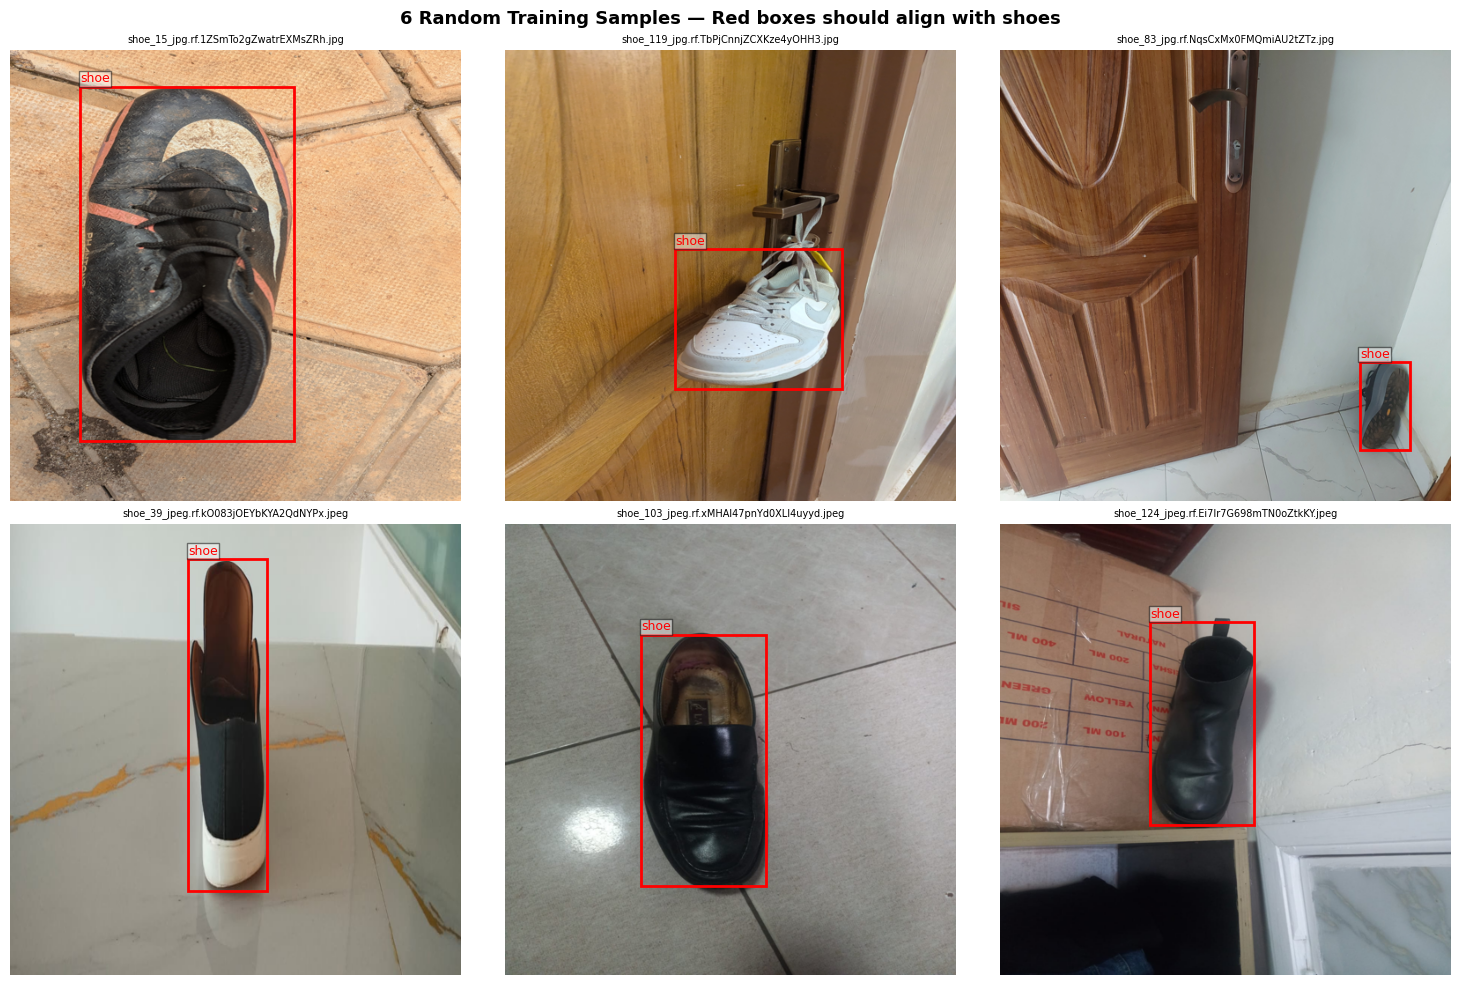

In [ ]:
# Visualise 6 random samples to verify EXIF fix and bounding boxes

dataset = ShoeDataset(ANNOT_FILE, DATA_DIR, IMG_SIZE)
print(f"Total usable images: {len(dataset)}")

# Pick 6 random indices
indices = random.sample(range(len(dataset)), 6)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, idx in enumerate(indices):
    img_tensor, target = dataset[idx]
    img_np = img_tensor.permute(1, 2, 0).numpy()

    axes[i].imshow(img_np)

    # Draw each bounding box
    for box in target["boxes"]:
        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor="red", facecolor="none")
        axes[i].add_patch(rect)
        axes[i].text(x1, y1 - 5, "shoe", color="red", fontsize=9, bbox=dict(facecolor="white", alpha=0.5, pad=1))

    # Show image filename as title
    img_info = dataset.images[dataset.ids[idx]]
    axes[i].set_title(img_info["file_name"], fontsize=7)
    axes[i].axis("off")

plt.suptitle("6 Random Training Samples — Red boxes should align with shoes", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [22]:
# Create dataset and split into train/val
def collate_fn(batch):
    return tuple(zip(*batch))

# 80% train, 20% val
n_train = int(0.8 * len(dataset))
n_val   = len(dataset) - n_train
train_set, val_set = torch.utils.data.random_split(dataset, [n_train, n_val])

train_loader = DataLoader(train_set, batch_size=2, shuffle=True,  collate_fn=collate_fn)
val_loader = DataLoader(val_set,   batch_size=2, shuffle=False, collate_fn=collate_fn)

print(f"Total images : {len(dataset)}")
print(f"Train samples: {n_train}")
print(f"Val samples  : {n_val}")

Total images : 146
Train samples: 116
Val samples  : 30


In [23]:
# Load pretrained Faster R-CNN and replace head for shoe detection
def get_model(num_classes):
    # Download weights pretrained on COCO (transfer learning)
    model = fasterrcnn_resnet50_fpn(weights="DEFAULT")

    # Replace the final classifier head to match our number of classes
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

model = get_model(NUM_CLASSES)
model.to(device)
print("Pretrained Faster R-CNN loaded and head replaced.")
print(f"Output classes: {NUM_CLASSES}  (0=background, 1=shoe)")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to C:\Users\mitch/.cache\torch\hub\checkpoints\fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100.0%


Pretrained Faster R-CNN loaded and head replaced.
Output classes: 2  (0=background, 1=shoe)
